# Non-Markovian HEOM dynamics on one continuous quantum grid

One state goes in at $t=0$, one fixed gate is applied $n$ times, one state comes
out at $t=n\Delta t$.  No intermediate tomography, no re-preparation, and -- the
point of this folder -- **not a single time step of the trajectory is computed
on the classical computer**.

The benchmark throughout is qutip's own `HEOMSolver` and nothing else, so every
number below says how far the grid is from the exact result rather than from
some other approximation.

---

## 1  Why the transfer-tensor / companion route hits a wall

HEOM is already a *closed linear* system.  Writing the reduced density matrix
together with all auxiliary density operators (ADOs) as one vector

$$
x(\tau)\;=\;\bigl(\operatorname{vec}\rho_S(\tau),\;\operatorname{vec}\rho_{\mathbf n_1}(\tau),\;\dots\bigr)\;\in\;\mathbb C^{n},
\qquad n=N_{\rm ADO}\,d^{2},
$$

the hierarchy is

$$
\frac{\mathrm d}{\mathrm d\tau}\,x(\tau)\;=\;A\,x(\tau),
\qquad
x(0)=\bigl(\operatorname{vec}\rho_S(0),0,\dots,0\bigr),
\qquad
\operatorname{vec}\rho_S(\tau)=\Pi\,x(\tau),
$$

with the projector $\Pi=[\,\mathbb 1_{d^2}\;0\;\cdots\;0\,]$ onto the zeroth ADO
block.  Hence, with $P=e^{A\Delta\tau}$,

$$
\boxed{\;\operatorname{vec}\rho_S(k\,\Delta\tau)\;=\;\Pi\,P^{\,k}\,x(0)\quad\text{exactly, for every }k .\;}
\tag{1.1}
$$

**Proposition 1.**  *The HEOM state vector evolves under a semigroup; all
non-Markovianity of $\rho_S$ comes from $\Pi$ not being invertible.  In
particular there is no memory length $K$ and no truncation in time.*

*Proof.*  $x(\tau)=e^{A\tau}x(0)$ with a time-independent $A$, so
$e^{A(\tau+\sigma)}=e^{A\tau}e^{A\sigma}$.  The reduced map
$\Lambda_\tau:\operatorname{vec}\rho_S(0)\mapsto\Pi e^{A\tau}\iota\,\operatorname{vec}\rho_S(0)$,
with $\iota$ the embedding into the zeroth block, is a compression of that
semigroup and generally fails $\Lambda_{\tau+\sigma}=\Lambda_\tau\Lambda_\sigma$
because $\iota\Pi\neq\mathbb 1$. $\square$

The transfer-tensor construction (Cerrillo & Cao, PRL **112**, 110401 (2014))
starts one level *below* this: it takes the reduced maps $L_k=\Pi P^k\iota$,
inverts the convolution

$$
T_n \;=\; L_n \;-\; \sum_{m=1}^{n-1} T_m\,L_{n-m},
\qquad
\operatorname{vec}\rho_S(n)\;=\;\sum_{m=1}^{K} T_m\,\operatorname{vec}\rho_S(n-m),
\tag{1.2}
$$

and packs the recursion into the block companion operator

$$
E=\begin{pmatrix}
T_1 & T_2 & \cdots & T_{K-1} & T_K\\
\mathbb 1 & 0 & \cdots & 0 & 0\\
0 & \mathbb 1 & \cdots & 0 & 0\\
 & & \ddots & & \vdots\\
0 & 0 & \cdots & \mathbb 1 & 0
\end{pmatrix}
\in\mathbb C^{Kd^2\times Kd^2}.
\tag{1.3}
$$

That does buy a fixed one-step operator, but at two structural costs:

1. every correlation older than $K\Delta t$ is **discarded** -- the sum in (1.2)
   is truncated;
2. the history window has to be filled, so the first $K$ states
   $\rho_S(0),\dots,\rho_S((K-1)\Delta t)$ must be produced **classically**
   before the grid can start.

Equation (1.1) says both are self-inflicted.  The ADOs *are* the memory; keeping
them costs a larger vector but removes $K$ from the problem entirely.

---

## 2  The real obstruction: $\lVert P\rVert_2 = 32.39$

A non-unitary $M$ is put on a grid by Sz.-Nagy dilation.  For $s\ge\lVert M\rVert_2$
set $M_s=M/s$ and

$$
U \;=\;
\begin{pmatrix}
M_s & \sqrt{\mathbb 1-M_sM_s^\dagger}\\[2pt]
\sqrt{\mathbb 1-M_s^\dagger M_s} & -M_s^\dagger
\end{pmatrix}.
\tag{2.1}
$$

**Proposition 2 (unitarity).**  *$U^\dagger U=\mathbb 1$.*

*Proof.*  Write $D=\sqrt{\mathbb 1-M_s^\dagger M_s}$ and
$\tilde D=\sqrt{\mathbb 1-M_sM_s^\dagger}$, both well defined and positive
semidefinite because $\lVert M_s\rVert_2\le1$.  The diagonal blocks of
$U^\dagger U$ are $M_s^\dagger M_s+D^2=\mathbb 1$ and
$\tilde D^2+M_sM_s^\dagger=\mathbb 1$.  The off-diagonal block is
$M_s^\dagger\tilde D-DM_s^\dagger$, which vanishes by the intertwining relation
$M_s^\dagger f(M_sM_s^\dagger)=f(M_s^\dagger M_s)M_s^\dagger$: it holds for
$f(z)=z^k$ by induction and hence for every polynomial, and by Weierstrass
approximation on the joint spectrum for $f=\sqrt{\;\cdot\;}$. $\square$

Applying $U$ to $|\psi\rangle\otimes|0\rangle_{\rm anc}$ and post-selecting the
ancilla on $|0\rangle$ realises $|\psi\rangle\mapsto M_s|\psi\rangle$.  Repeating
this $n$ times and demanding every ancilla read $0$ succeeds with probability

$$
p_n\;=\;\frac{\lVert M^{\,n}x\rVert^2}{s^{2n}\,\lVert x\rVert^2}.
\tag{2.2}
$$

The numerator is bounded -- the HEOM trajectory neither grows nor vanishes,
$\lVert P^nx\rVert/\lVert x\rVert\in[0.45,1]$ over the whole run, and the
spectral radius is exactly $\rho(P)=1$.  The denominator is not:
$\lVert P\rVert_2=32.39$, so $p_{100}\approx32^{-200}\approx10^{-301}$.

**Proposition 3 (this is not a step-size problem).**  *Let $T=n\Delta\tau$ be
fixed and $s(\Delta\tau)=\lVert e^{A\Delta\tau}\rVert_2$.  Then*

$$
\lim_{\Delta\tau\to0}\;n\,\ln s(\Delta\tau)\;=\;T\,\omega(A),
\qquad
\omega(A)=\lambda_{\max}\!\Bigl(\tfrac{A+A^\dagger}{2}\Bigr),
\tag{2.3}
$$

*so refining the grid drives the exponent to a finite positive limit set by the
numerical abscissa $\omega(A)$, not to zero.*

*Proof.*  $\lVert e^{A\Delta\tau}\rVert_2=1+\omega(A)\,\Delta\tau+O(\Delta\tau^2)$
by the logarithmic-norm expansion
$\frac{\mathrm d}{\mathrm d\tau}\lVert e^{A\tau}\rVert\big|_{\tau=0^+}=\omega(A)$.
Hence $n\ln s=\frac{T}{\Delta\tau}\bigl(\omega\Delta\tau+O(\Delta\tau^2)\bigr)\to T\omega$. $\square$

For this model $\omega(A)=+2.61\times10^{3}\,\mathrm{cm}^{-1}$ and
$T=0.1884\,\mathrm{cm}$, so $T\omega\approx4.9\times10^{2}$ and $p\approx e^{-984}$
*however the time axis is discretised*.  Three repairs were measured and ruled
out before what follows:

| attempt | measured result |
|---|---|
| Arnoldi/Krylov compression of $P$ directly | $\lVert H_m\rVert\approx32$, trajectory diverges to $10^{65}$ |
| diagonal balancing of $A$ (`scipy.linalg.matrix_balance`) | $\lVert P\rVert:32.4\to2.54$; still fatal, $2.54^{200}=10^{81}$ |
| Trotter split $A=A_{\rm ah}+A_{\rm h}$ | $\lambda_{\max}(A_{\rm h})=+2613>0$: the "dissipative" factor is not a contraction |

## 3  The fix: a metric in which $A$ *is* dissipative

$\lVert P\rVert_2=32$ is a statement about the Euclidean inner product, not about
the physics.  Choose instead $W\succ0$ and work with
$\langle x,y\rangle_W=x^\dagger Wy$, $\lVert x\rVert_W=\lVert W^{1/2}x\rVert_2$.

**Theorem 4 (Lyapunov gauge).**  *Let $\delta>0$ be such that $A-\delta\mathbb 1$
is Hurwitz, and let $Q\succ0$.  Then*

$$
W\;=\;\int_0^\infty e^{-2\delta\tau}\,e^{A^\dagger\tau}\,Q\,e^{A\tau}\,\mathrm d\tau
\tag{3.1}
$$

*converges, is the unique positive definite solution of*

$$
(A-\delta\mathbb 1)^\dagger W+W(A-\delta\mathbb 1)\;=\;-\,Q,
\tag{3.2}
$$

*and satisfies*

$$
\lVert e^{A\tau}\rVert_W\;\le\;e^{\delta\tau}\qquad\text{for all }\tau\ge0 .
\tag{3.3}
$$

*Proof.*  Convergence: $A-\delta$ Hurwitz gives
$\lVert e^{(A-\delta)\tau}\rVert\le c\,e^{-\eta\tau}$ for some $c,\eta>0$, and the
integrand of (3.1) is bounded by $\lVert Q\rVert\,c^2e^{-2\eta\tau}$.  Positive
definiteness is immediate from $Q\succ0$.  That (3.1) solves (3.2) follows from

$$
\frac{\mathrm d}{\mathrm d\tau}\Bigl(e^{-2\delta\tau}e^{A^\dagger\tau}Qe^{A\tau}\Bigr)
= e^{-2\delta\tau}e^{A^\dagger\tau}\bigl[(A-\delta)^\dagger Q'+Q'(A-\delta)\bigr]e^{A\tau}
$$

integrated from $0$ to $\infty$, the boundary term at $\infty$ vanishing and the
one at $0$ giving $-Q$; uniqueness holds because $\operatorname{spec}(A-\delta)$
and $-\operatorname{spec}(A-\delta)^{*}$ are disjoint, so the Sylvester operator
$X\mapsto(A-\delta)^\dagger X+X(A-\delta)$ is invertible.  For (3.3) put
$x(\tau)=e^{A\tau}x_0$ and $V(\tau)=x(\tau)^\dagger Wx(\tau)$:

$$
V'(\tau)=x^\dagger\bigl(A^\dagger W+WA\bigr)x
        =x^\dagger\bigl(-Q+2\delta W\bigr)x
        \;\le\;2\delta\,V(\tau),
$$

using (3.2) and $Q\succ0$.  Grönwall gives $V(\tau)\le e^{2\delta\tau}V(0)$, i.e.
$\lVert x(\tau)\rVert_W\le e^{\delta\tau}\lVert x_0\rVert_W$. $\square$

Theorem 4 needs nothing beyond $\operatorname{Re}\lambda\le0$ for every
eigenvalue of $A$, which holds for any HEOM generator: the measured spectral
abscissa here is $-2.3\times10^{-8}\,\mathrm{cm}^{-1}$, i.e. zero to numerical
precision, the zero eigenvalue being the steady state.  Then $A-\delta$ is
Hurwitz for *every* $\delta>0$.  $\delta>0$ is needed only
because of that one marginal eigenvalue: at $\delta=0$ the integral (3.1) would
diverge along the steady state.

**Corollary 5.**  *Define the gauged propagator $\tilde P=W^{1/2}PW^{-1/2}$ with
$P=e^{A\Delta\tau}$.  Then $\lVert\tilde P\rVert_2\le e^{\delta\Delta\tau}$, and
$\tilde P$ is similar to $P$, so*

$$
\operatorname{vec}\rho_S(k\Delta\tau)\;=\;\Pi\,W^{-1/2}\,\tilde P^{\,k}\,\tilde x_0,
\qquad \tilde x_0=W^{1/2}x_0,
\tag{3.4}
$$

*is exact -- the gauge introduces no approximation whatsoever.*

*Proof.*  $\lVert\tilde P\rVert_2=\lVert e^{A\Delta\tau}\rVert_W\le e^{\delta\Delta\tau}$
by (3.3) and the definition of $\lVert\cdot\rVert_W$; similarity gives
$\tilde P^{\,k}=W^{1/2}P^kW^{-1/2}$, and (3.4) is (1.1) with
$\mathbb 1=W^{-1/2}W^{1/2}$ inserted. $\square$

Now (2.2) is read with $s=e^{\delta\Delta\tau}\approx1$ instead of $s=32.39$:

$$
p_n\;=\;\frac{\lVert\tilde P^{\,n}\tilde x_0\rVert^2}{\lVert\tilde x_0\rVert^2}\;e^{-2\delta T},
\tag{3.5}
$$

which is $O(1)$.  What survives is the genuine physical relaxation of the state
towards equilibrium, times a factor $e^{-2\delta T}$ under our control.

**The price of $\delta$.**  Over a run of length $T$ the gauge costs exactly
$e^{-2\delta T}$ in (3.5), so the only requirement is $\delta T\ll1$ and $\delta$
is simply lowered for longer runs.  It is *not* traded against conditioning:
$\operatorname{cond}(W)$ was measured as $1.68\times10^{10}$ at $\delta=0.1$ and
$7.5\times10^{9}$ at $\delta=10$ -- essentially flat, because the condition
number is set by the spread of the ADO scales, not by the shift.

---

## 4  Krylov compression is free in the gauge

The gauged propagator still lives on $\mathbb C^{2640}$.  Compress it onto the
$m$-dimensional Krylov space $\mathcal K_m(\tilde P,\tilde x_0)$ with an
orthonormal Arnoldi basis $Q_m$:

$$
\tilde P\,Q_m \;=\; Q_m H_m \;+\; h_{m+1,m}\,q_{m+1}e_m^{\mathsf T},
\qquad H_m=Q_m^\dagger\tilde PQ_m .
\tag{4.1}
$$

**Proposition 6.**  *$\lVert H_m\rVert_2\le\lVert\tilde P\rVert_2$ for every $m$.*

*Proof.*  $Q_m$ is an isometry, so for any $y$,
$\lVert H_my\rVert=\lVert Q_m^\dagger\tilde PQ_my\rVert\le\lVert\tilde PQ_my\rVert
\le\lVert\tilde P\rVert\,\lVert Q_my\rVert=\lVert\tilde P\rVert\,\lVert y\rVert$. $\square$

This is the second half of the argument, and the reason the gauge has to come
*first*.  Compressing the raw $P$ produces $\lVert H_m\rVert\approx32$ and a
trajectory that blows up; compressing $\tilde P$ produces a contraction for
*every* $m$, so $m$ can be raised until the accuracy is whatever we want, at no
cost in $p_n$ and at only logarithmic cost in qubits.  Together with the
standard Arnoldi exactness property

$$
H_m^{\,k}\,Q_m^\dagger\tilde x_0 \;=\; Q_m^\dagger\tilde P^{\,k}\tilde x_0
\qquad\text{for } k\le m-1,
\tag{4.2}
$$

the first $m$ steps are reproduced to machine precision, and the rest is
governed by how well the Ritz values approximate the slow spectrum of
$\tilde P$ -- which is exactly where Arnoldi converges fastest, since for a
contraction the extremal eigenvalues $|\lambda|\to1$ *are* the long-lived modes.

The readout is the linear functional

$$
\operatorname{vec}\rho_S(k\Delta\tau)\;=\;R\,y_k,
\qquad
R=\bigl(W^{-1/2}Q_m\bigr)_{[\,1:d^2,\;:\,]},
\qquad
y_k=H_m^{\,k}\,y_0,\quad y_0=\lVert\tilde x_0\rVert\,e_1 .
\tag{4.3}
$$

## 5  The grid

$H_m$ is padded to $m_p=2^{\lceil\log_2m\rceil}$ and dilated once by (2.1) into a
single unitary $U$ on $\lceil\log_2m\rceil+1$ qubits.  The circuit is then
literally one gate repeated, with the ancilla measured into its own classical
bit and reset:

```
 krylov  ────┤     ├──────────┤     ├──────────┤     ├───   ...
             │  U  │          │  U  │          │  U  │
 anc    ─|0>─┤     ├─M──|0>───┤     ├─M──|0>───┤     ├─M─   ...
                    │                │                │
 rec    ────────────●────────────────●────────────────●───
```

No state preparation is needed: $y_0=\lVert\tilde x_0\rVert\,e_1$ by construction
of the Arnoldi basis, so the register starts in $|0\cdots0\rangle$ already.  After
$t$ repetitions with every ancilla reading $0$ the krylov register holds
$H_m^ty_0/\lVert H_m^ty_0\rVert$, and the measurement record itself supplies the
missing norm,

$$
\lVert y_t\rVert\;=\;s^{\,t}\,\sqrt{p_t}\;\lVert y_0\rVert .
\tag{5.1}
$$

**Proposition 7 (the accepted branch is deterministic).**  *Conditioned on the
record $0\cdots0$, the state of the krylov register after step $t$ is
$H_m^{\,t}y_0/\lVert H_m^{\,t}y_0\rVert$, independent of any randomness in the
measurements.*

*Proof.*  By induction.  Suppose the register is in the pure state
$|y_{t-1}\rangle|0\rangle_{\rm anc}$ before step $t$.  By (2.1),

$$
U\,|y_{t-1}\rangle|0\rangle \;=\; \bigl(M_s|y_{t-1}\rangle\bigr)|0\rangle
\;+\;\bigl(D\,|y_{t-1}\rangle\bigr)|1\rangle,
\qquad M_s=H_m/s,\;\; D=\sqrt{\mathbb 1-M_s^\dagger M_s}.
$$

Measuring the ancilla and obtaining $0$ projects onto the first summand;
renormalising gives $M_s|y_{t-1}\rangle/\lVert M_sy_{t-1}\rVert$, a function of
$y_{t-1}$ alone.  Resetting the ancilla restores the hypothesis.  Since $y_0$ is
fixed and $M_s\propto H_m$, the accepted state after $t$ steps is
$\propto H_m^{\,t}y_0$. $\square$

Two things follow.  First, a *single* accepted shot already carries the exact
state -- the record is random, the state conditioned on it is not.  Only the
scalar $p_t$ is estimated statistically, and the alternative readout through
$\operatorname{Tr}\rho_S(t)=1$ does not need even that.

Second, it settles how the circuit must be simulated.  Aer implements a
mid-circuit measurement by *sampling* an outcome, in the density-matrix method
exactly as in the statevector method: a two-qubit test with an exact $0.3/0.7$
split returns $[0,1]$ at one shot and $[0.284,0.716]$ at $1024$.  Reading the
post-selected branch out of a saved density matrix -- for instance by measuring
the ancilla and conditionally dumping failures into a sink state -- therefore
carries a $1/\sqrt{\rm shots}$ error.  `save_statevector(conditional=True)`
groups the saved states by the classical record instead and returns the accepted
branch itself, which by Proposition 7 is exact.

---

## 6  Where the work happens

| step | cost | scales with the number of time steps? |
|---|---|---|
| assemble $A$ | sparse, from qutip | no |
| Lyapunov solve (3.2) | $O(n^3)$, $\approx90$ s at $n=2640$ | no |
| $P=e^{A\Delta\tau}$ | $O(n^3)$, $\approx37$ s | no |
| Arnoldi (4.1) | $m$ matrix-vector products | no |
| dilation (2.1) | $O(m^3)$, $m\le128$ | no |
| **propagation** | $n$ applications of one gate on $\lceil\log_2m\rceil+1$ qubits | **on the grid** |

Classically propagated time steps: **zero**, for any $T$.  The companion route
needs $K$ of them before it can start, and a direct classical solve needs all
$n$ of them.

**What this does and does not claim.**  The setup is not free: the Lyapunov
solve and the matrix exponential are $O(n^3)$ operations on the full
$2640\times2640$ ADO space, and for a system this small that is comparable to
just solving the dynamics classically.  The claim is about *scaling*, not about
beating qutip on a 4-site model: the classical cost here is $O(1)$ in the number
of time steps and in the total time $T$, whereas the companion route pays $K$
propagation steps and a classical solve pays $n$.  Pushing the setup itself onto
cheaper ground -- a physically motivated diagonal ADO rescaling in place of the
Lyapunov solve, a Krylov exponential in place of `expm` -- is the obvious next
step and is not done here.  A diagonal gauge alone is known not to be enough:
`scipy.linalg.matrix_balance` only reaches $\lVert P\rVert=2.54$.

In [1]:
import os, sys, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from heom_gauge import (build_grid, regrid, save_grid, load_grid,
                        qutip_reference, reference_trajectory,
                        companion_baseline, post_selection_curve)
from gauge_circuit import build_circuit, run_grid, run_grid_final

PIC, DATA = 'pictures', 'data'
os.makedirs(PIC, exist_ok=True)
os.makedirs(DATA, exist_ok=True)

In [2]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

# The one-off construction is O(n^3) in n = N_ADO * d^2, and the Lyapunov
# solve needs several n x n matrices in memory at once.  N=4 / depth 3 gives
# 165 ADOs -> n = 2640 (~110 MB per matrix), which is comfortable.  N=7 forces
# depth 2 (120 ADOs -> n = 5880, ~550 MB per matrix and roughly half an hour);
# N=7 at depth 3 is 680 ADOs -> n = 33320, i.e. ~18 GB per matrix, out of reach.
N = 4                                    # 4-site or 7-site FMO
if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 50.0, 300.0

MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0 = np.diag([1.0] + [0.0] * (N - 1))   # excitation on site 1

dt_fs      = 10.0
HEOM_depth = 3
N_STEPS    = 100          # 1 ps
DELTA      = 0.02         # Lyapunov shift [cm^-1], eq. (3.2); only needs delta*T << 1
M_KRYLOV   = 128          # Krylov dimension, eq. (4.1)
SHOTS      = 512          # only p_t is statistical -- the state is not (Prop. 7)

t_fs = np.arange(N_STEPS + 1) * dt_fs
cols = plt.cm.tab10(np.arange(N))
print(f"{N}-site FMO, dt = {dt_fs} fs, T = {t_fs[-1]:.0f} fs, HEOM depth {HEOM_depth}")

4-site FMO, dt = 10.0 fs, T = 1000 fs, HEOM depth 3


## 7  Build the grid

Everything in this cell is done **once** and none of it scales with the number
of time steps: the HEOM generator, one Lyapunov solve, one matrix exponential,
$m$ Arnoldi matrix-vector products and one dilation.

In [3]:
t0 = time.time()
grid = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                  depth=HEOM_depth, **MODEL)
print(f"one-off construction: {time.time() - t0:.1f} s")
save_grid(f'{DATA}/grid_N{N}_m{grid["m"]}.npz', grid)

P, Pt = grid['P'], grid['Pt']
A_herm = 0.5 * (grid['A'] + grid['A'].conj().T)
print()
print(f"  ||P||_2                = {np.linalg.norm(P, 2):12.4f}")
print(f"  spectral radius rho(P) = {max(abs(np.linalg.eigvals(grid['Hm']))):12.6f}")
print(f"  numerical abscissa     = {np.linalg.eigvalsh(A_herm).max():12.4e} cm^-1  (eq. 2.3)")
print(f"  ||P~||_2               = {np.linalg.norm(Pt, 2):12.6f}   "
      f"bound e^(delta dt) = {np.exp(DELTA * grid['dt_cm']):.6f}")
print(f"  cond(W)                = {grid['gauge']['cond']:12.3e}")
print(f"  grid                   = {grid['n_qubits']} qubits, one "
      f"{2*grid['mp']}x{2*grid['mp']} gate")
print(f"  Sz.-Nagy scale s       = {grid['s']:.8f}   "
      f"s^{N_STEPS} = {grid['s']**N_STEPS:.4f}")

  A: 2640 x 2640 (165 ADOs)


  gauge delta=0.02 cm^-1: cond(W)=1.74e+10, ||P||=32.3922 -> ||P~||=1.000038 (bound 1.000038)


  Krylov m=128 -> 8 qubits, ||H_m||=1.000038, s=1.000038, s^100=1.0038


one-off construction: 183.0 s


  ||P||_2                =      32.3922
  spectral radius rho(P) =     1.000000


  numerical abscissa     =   2.6135e+03 cm^-1  (eq. 2.3)


  ||P~||_2               =     1.000038   bound e^(delta dt) = 1.000038
  cond(W)                =    1.739e+10
  grid                   = 8 qubits, one 256x256 gate
  Sz.-Nagy scale s       = 1.00003767   s^100 = 1.0038


## 8  The benchmark: qutip's own `HEOMSolver`

The only reference used anywhere in this folder.

In [4]:
t0 = time.time()
pops_qutip = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)
print(f"qutip HEOMSolver: {time.time() - t0:.2f} s, {pops_qutip.shape}")

10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00


30.0%. Run time:   0.08s. Est. time left: 00:00:00:00


40.0%. Run time:   0.10s. Est. time left: 00:00:00:00


50.0%. Run time:   0.12s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.17s. Est. time left: 00:00:00:00


80.0%. Run time:   0.20s. Est. time left: 00:00:00:00


90.0%. Run time:   0.22s. Est. time left: 00:00:00:00


100.0%. Run time:   0.24s. Est. time left: 00:00:00:00


Total run time:   0.24s
qutip HEOMSolver: 0.28 s, (101, 4)


## 9  The grid, in Qiskit

One circuit, `N_STEPS` repetitions of the single gate $U$, the ancilla measured
into its own classical bit and reset after each.  Every intermediate time is
read out of that **one** run through `save_statevector(conditional=True)`.

Two readouts are reported.  `pops_tr` normalises the accepted branch with
$\operatorname{Tr}\rho_S(t)=1$; by Proposition 7 that branch is exact, so this
readout carries no statistical error at all.  `pops` instead restores
$\lVert y_t\rVert$ from the acceptance rate via (5.1) and therefore fluctuates
with $1/\sqrt{N_{\rm acc}}$ -- section 15 shows it converging.  The two use
disjoint information, so their agreement is a self-contained check on sections
3-5.

In [5]:
t0 = time.time()
pops_grid, pops_tr, info = run_grid(grid, N_STEPS, shots=SHOTS, save_every=1)
print(f"  simulation: {time.time() - t0:.1f} s")

idx = info['t_index']
err_grid = np.abs(pops_tr - pops_qutip[idx]).max()
err_p    = np.abs(pops_grid - pops_qutip[idx]).max()
print()
print(f"  QUANTUM GRID vs qutip HEOMSolver          : {err_grid:.3e}")
print(f"  same, norm from the record (eq. 5.1)      : {err_p:.3e}   "
      f"({SHOTS} shots)")
print(f"  post-selection probability                : {info['p_success'][0]:.4f} -> "
      f"{info['p_success'][-1]:.4f}")

  grid: 8 qubits, 100 applications of one gate, circuit depth 300, 512 shots


  post-selection probability: 1.0000 -> 0.3555


  simulation: 23.6 s

  QUANTUM GRID vs qutip HEOMSolver          : 5.268e-07
  same, norm from the record (eq. 5.1)      : 1.343e-02   (512 shots)
  post-selection probability                : 1.0000 -> 0.3555


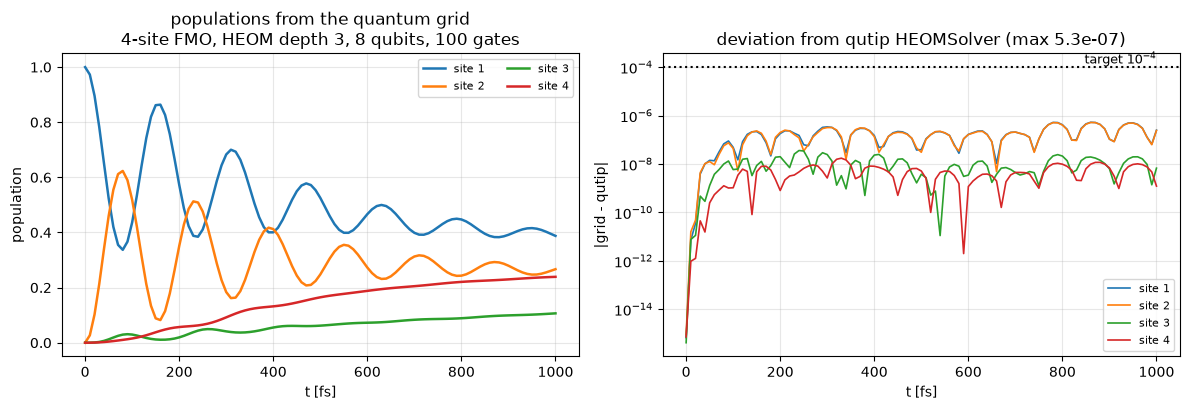

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i in range(N):
    ax[0].plot(idx * dt_fs, pops_tr[:, i], color=cols[i], lw=1.8,
               label=f'site {i+1}')
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('population')
ax[0].set_title(f'populations from the quantum grid\n{N}-site FMO, HEOM depth '
                f'{HEOM_depth}, {grid["n_qubits"]} qubits, {N_STEPS} gates')
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)

for i in range(N):
    ax[1].semilogy(idx * dt_fs, np.abs(pops_tr[:, i] - pops_qutip[idx, i]) + 1e-18,
                   color=cols[i], lw=1.2, label=f'site {i+1}')
ax[1].axhline(1e-4, color='k', ls=':', lw=1.5)
ax[1].text(t_fs[-1], 1.35e-4, r'target $10^{-4}$', ha='right', fontsize=9)
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel('|grid - qutip|')
ax[1].set_title(f'deviation from qutip HEOMSolver (max {err_grid:.1e})')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/grid_vs_qutip_N{N}.png', dpi=160)
plt.show()

## 10  Why the gauge is the whole story

Equation (2.2) is a product of two factors, $1/s^{2n}$ and
$\lVert M^nx\rVert^2/\lVert x\rVert^2$.  In the Euclidean metric **both** are
astronomical and very nearly -- but not nearly enough -- cancel.  The left panel
shows why the second one blows up: almost all of the Euclidean norm of
$\vec\Sigma$ sits in the ADOs, which are bookkeeping objects for the bath
correlations, not density matrices, and nothing requires them to stay bounded.
The physical part is perfectly well behaved the whole time.

The gauge measures the same trajectory with a yardstick under which it is a
contraction, and then each factor separately is $O(1)$.

  ||Sigma_n||/||Sigma_0||: max 3165, final 1101
  of which the system block is 5.209e-04
  ||vec rho_S(T)|| = 0.573457   Tr rho_S(T) = 1.000000


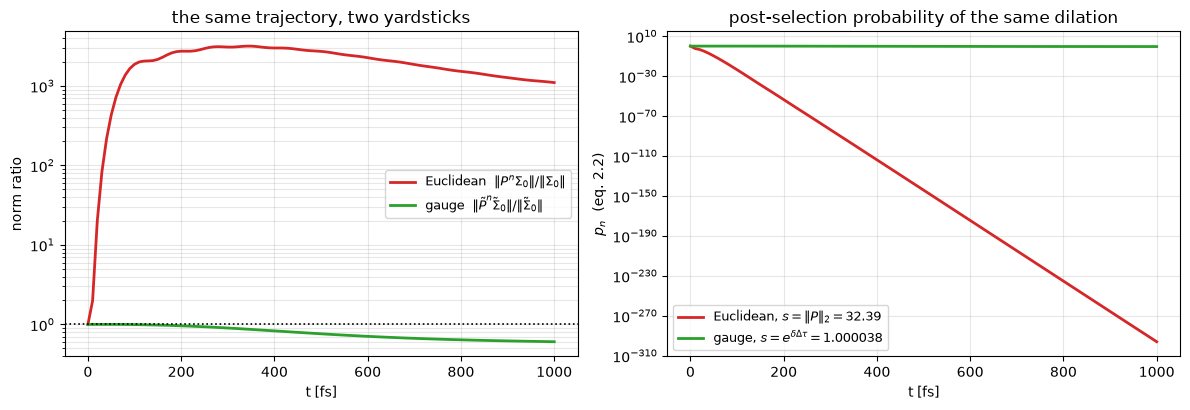


  Euclidean: p(100) = 9.899e-297   = 8.166e-303 (part 1) x 1.212e+06 (part 2)
  gauge    : p(100) = 3.646e-01   ratio 3.68e+295


In [7]:
x0 = np.zeros(grid['A'].shape[0], complex)
x0[:grid['D']] = rho0.flatten(order='F')
xt0 = grid['Wh'] @ x0

s_raw = float(np.linalg.norm(P, 2))
p_raw = post_selection_curve(P,  x0,  N_STEPS, s_raw)
p_gau = post_selection_curve(Pt, xt0, N_STEPS, grid['s'])
n_raw = np.sqrt(post_selection_curve(P,  x0,  N_STEPS, 1.0))   # ||P^n x||/||x||
n_gau = np.sqrt(post_selection_curve(Pt, xt0, N_STEPS, 1.0))

# what fraction of the Euclidean norm is the physical state at the end?
x = x0.copy()
for _ in range(N_STEPS):
    x = P @ x
rho_end = x[:grid['D']].reshape(N, N, order='F')
print(f"  ||Sigma_n||/||Sigma_0||: max {n_raw.max():.4g}, final {n_raw[-1]:.4g}")
print(f"  of which the system block is {np.linalg.norm(x[:grid['D']])/np.linalg.norm(x):.3e}")
print(f"  ||vec rho_S(T)|| = {np.linalg.norm(x[:grid['D']]):.6f}   "
      f"Tr rho_S(T) = {np.real(np.trace(rho_end)):.6f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(t_fs, n_raw, lw=2, color='C3',
               label=r'Euclidean  $\|P^n\Sigma_0\|/\|\Sigma_0\|$')
ax[0].semilogy(t_fs, n_gau, lw=2, color='C2',
               label=r'gauge  $\|\tilde P^n\tilde\Sigma_0\|/\|\tilde\Sigma_0\|$')
ax[0].axhline(1, color='k', ls=':', lw=1.2)
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('norm ratio')
ax[0].set_title('the same trajectory, two yardsticks')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3, which='both')

ax[1].semilogy(t_fs, np.maximum(p_raw, 1e-320), lw=2, color='C3',
               label=rf'Euclidean, $s=\|P\|_2={s_raw:.2f}$')
ax[1].semilogy(t_fs, p_gau, lw=2, color='C2',
               label=rf'gauge, $s=e^{{\delta\Delta\tau}}={grid["s"]:.6f}$')
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel(r'$p_n$  (eq. 2.2)')
ax[1].set_title('post-selection probability of the same dilation')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/gauge_postselection_N{N}.png', dpi=160)
plt.show()

print(f"\n  Euclidean: p({N_STEPS}) = {p_raw[-1]:.3e}   "
      f"= {1/s_raw**(2*N_STEPS):.3e} (part 1) x {n_raw[-1]**2:.3e} (part 2)")
print(f"  gauge    : p({N_STEPS}) = {p_gau[-1]:.3e}   "
      f"ratio {p_gau[-1] / max(p_raw[-1], 1e-320):.2e}")

## 11  Convergence in the Krylov dimension $m$

Proposition 6 guarantees $\lVert H_m\rVert\le\lVert\tilde P\rVert$ for every $m$,
so raising $m$ costs nothing except $\lceil\log_2m\rceil$ qubits.  `regrid`
reuses the gauge, so a scan over $m$ costs only $m$ matrix-vector products per
point.

The floor at $\approx5\times10^{-7}$ is the qutip solver's own integration
tolerance, not ours: iterating the full $2640\times2640$ propagator $P$ directly,
with no compression and no gauge, reproduces exactly the same number.

In [8]:
scan = {}
for m_try in (16, 32, 64, 96, 128):
    g = regrid(grid, m_try)
    pk = reference_trajectory(g, N_STEPS)
    scan[g['m']] = (g['n_qubits'], float(np.linalg.norm(g['Hm'], 2)),
                    np.abs(pk - pops_qutip).max(),
                    post_selection_curve(g['Hm'], g['y0'], N_STEPS, g['s'])[-1])
    print(f"  m={g['m']:4d}  qubits={scan[g['m']][0]:2d}  "
          f"||H_m||={scan[g['m']][1]:.6f}  vs qutip={scan[g['m']][2]:.3e}  "
          f"p({N_STEPS})={scan[g['m']][3]:.3e}")

x, pfull = x0.copy(), []
for _ in range(N_STEPS + 1):
    pfull.append(np.real(np.diag(x[:grid['D']].reshape(N, N, order='F'))))
    x = P @ x
print(f"\n  full P, no Krylov and no gauge    vs qutip = "
      f"{np.abs(np.array(pfull) - pops_qutip).max():.3e}   <- solver tolerance")

  m=  16  qubits= 5  ||H_m||=1.000038  vs qutip=1.926e-01  p(100)=1.723e-01


  m=  32  qubits= 6  ||H_m||=1.000038  vs qutip=6.217e-02  p(100)=3.321e-01


  m=  64  qubits= 7  ||H_m||=1.000038  vs qutip=5.267e-07  p(100)=3.646e-01


  m=  96  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01


  m= 128  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01



  full P, no Krylov and no gauge    vs qutip = 5.268e-07   <- solver tolerance


## 12  Robustness across the parameter range, and where it breaks

The gauge guarantees $\lVert\tilde P\rVert_2\le e^{\delta\Delta\tau}$ (Theorem 4),
so comparing the measured norm against that bound is a **free validity check**:
if it is exceeded, the arithmetic has failed, not the theory.  Forming $W$ and
then taking $W^{\pm1/2}$ squares the condition number, so a generator with a
large transient can push $\mathrm{cond}(W)$ past what float64 carries.
`build_grid` raises a `RuntimeWarning` when that happens -- the second case
below deliberately triggers it.

In [9]:
import warnings

cases = [('reference        ', LAM_FMO, GAM_FMO, T_FMO),
         ('strong coupling  ',   35.0,   106.14,  300.0),
         ('very strong      ',  100.0,     50.0,  300.0)]
print(f"{'case':18s} {'||P||':>12s} {'||P~||':>10s} {'bound':>9s} {'cond(W)':>9s} "
      f"{'vs qutip':>10s} {'p(100)':>10s}  ok?")
for name, lam, gam, T_K in cases:
    M2 = dict(MODEL); M2.update(lam=lam, gamma=gam, T_K=T_K)
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            g2 = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                            depth=HEOM_depth, verbose=False, **M2)
        ref2 = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **M2)
        pk2  = reference_trajectory(g2, N_STEPS)
        p2_  = post_selection_curve(g2['Hm'], g2['y0'], N_STEPS, g2['s'])[-1]
        gi   = g2['gauge']
        print(f"{name:18s} {gi['norm_P']:12.4g} {gi['norm_Pt']:10.4f} {gi['bound']:9.6f} "
              f"{gi['cond']:9.2e} {np.abs(pk2-ref2).max():10.3e} {p2_:10.3e}  "
              f"{'yes' if gi['trustworthy'] else 'NO'}")
        for w in caught:
            print(f"      -> {w.category.__name__}: {str(w.message)[:105]}...")
    except Exception as e:
        print(f"{name:18s} {'':>12s} {'':>10s} {'':>9s} {'':>9s} {'':>10s} {'':>10s}  "
              f"FAILED: {type(e).__name__}: {str(e)[:60]}")

case                      ||P||     ||P~||     bound   cond(W)   vs qutip     p(100)  ok?


10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.06s. Est. time left: 00:00:00:00


30.0%. Run time:   0.09s. Est. time left: 00:00:00:00


40.0%. Run time:   0.11s. Est. time left: 00:00:00:00


...

70.0%. Run time:   0.24s. Est. time left: 00:00:00:00


80.0%. Run time:   0.26s. Est. time left: 00:00:00:00


90.0%. Run time:   0.29s. Est. time left: 00:00:00:00


100.0%. Run time:   0.31s. Est. time left: 00:00:00:00


Total run time:   0.31s
very strong           7.713e+05     6.5428  1.000038  2.25e+19  5.792e-08 2.881e-137  NO
      -> RuntimeWarning: gauge lost precision: ||P~||_2 = 6.543 exceeds the guaranteed bound exp(delta*dt) = 1.00004 by a factor 6...


## 13  Comparison with the transfer-tensor / companion route

Same model, same benchmark.  The middle column counts the time steps that have
to be produced on the classical computer before the grid can start.

In [10]:
comp = {}
for K in (10, 25, 40):
    pc, E = companion_baseline(P, K, N, rho0, N_STEPS)
    comp[K] = (np.abs(pc - pops_qutip).max(), pc, float(np.linalg.norm(E, 2)))
    print(f"  companion K={K:3d}: {K:3d} classical steps "
          f"({100*K/N_STEPS:3.0f} % of the run), vs qutip = {comp[K][0]:.3e}, "
          f"||E||_2 = {comp[K][2]:.3f}")
print(f"\n  this folder      :   0 classical steps (  0 % of the run), "
      f"vs qutip = {err_grid:.3e}")

  companion K= 10:  10 classical steps ( 10 % of the run), vs qutip = 5.657e-02, ||E||_2 = 1.414


  companion K= 25:  25 classical steps ( 25 % of the run), vs qutip = 5.580e-03, ||E||_2 = 1.414


  companion K= 40:  40 classical steps ( 40 % of the run), vs qutip = 9.029e-04, ||E||_2 = 1.414

  this folder      :   0 classical steps (  0 % of the run), vs qutip = 5.268e-07


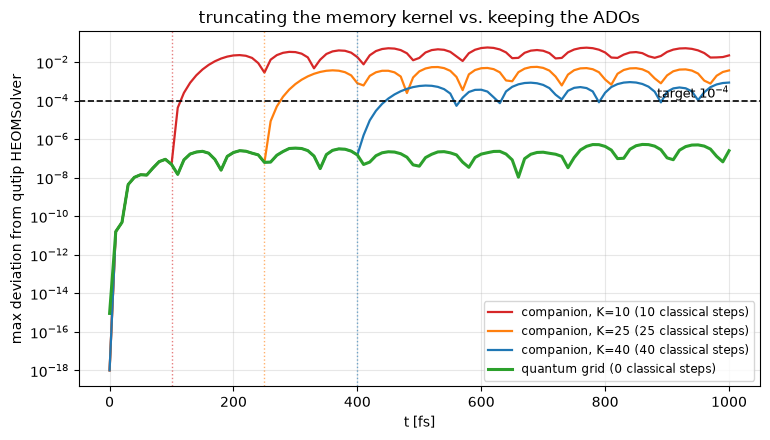

In [11]:
fig, ax = plt.subplots(figsize=(7.8, 4.5))
for K, c in zip((10, 25, 40), ('C3', 'C1', 'C0')):
    ax.semilogy(t_fs, np.abs(comp[K][1] - pops_qutip).max(axis=1) + 1e-18,
                color=c, lw=1.6, label=f'companion, K={K} ({K} classical steps)')
    ax.axvline(K * dt_fs, color=c, ls=':', lw=1, alpha=.6)
ax.semilogy(idx * dt_fs, np.abs(pops_tr - pops_qutip[idx]).max(axis=1) + 1e-18,
            color='C2', lw=2.2, label='quantum grid (0 classical steps)')
ax.axhline(1e-4, color='k', ls='--', lw=1.2)
ax.text(t_fs[-1], 1.35e-4, r'target $10^{-4}$', ha='right', fontsize=9)
ax.set_xlabel('t [fs]'); ax.set_ylabel('max deviation from qutip HEOMSolver')
ax.set_title('truncating the memory kernel vs. keeping the ADOs')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/vs_companion_N{N}.png', dpi=160)
plt.show()

## 14  Long runs

Proposition 6 makes $\lVert H_m\rVert\le e^{\delta\Delta\tau}$, so the iteration
cannot blow up: the grid is unconditionally stable however long it runs.  The
only drift is the deliberate factor $e^{-2\delta T}$ of (3.5), which is why
$\delta$ is kept small.

10.0%. Run time:   0.11s. Est. time left: 00:00:00:01


20.0%. Run time:   0.21s. Est. time left: 00:00:00:00


30.0%. Run time:   0.37s. Est. time left: 00:00:00:00


40.0%. Run time:   0.50s. Est. time left: 00:00:00:00


50.0%. Run time:   0.59s. Est. time left: 00:00:00:00


...

100.0%. Run time:   1.09s. Est. time left: 00:00:00:00


Total run time:   1.09s


  grid: 8 qubits, 500 applications of one gate, circuit depth 1500, 512 shots


  post-selection probability: 1.0000 -> 0.2441


  simulation: 97.7 s
  500 steps = 5 ps on one grid
  QUANTUM GRID vs qutip HEOMSolver : 1.853e-06
  norm from the record (eq. 5.1)   : 1.193e-02
  post-selection probability       : 1.0000 -> 0.2441   (plateaus once the state has relaxed)


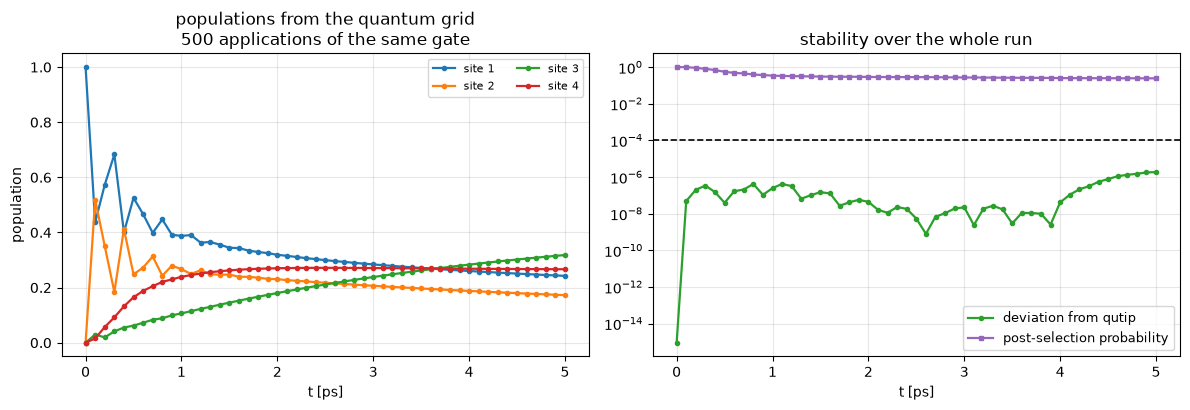

In [12]:
N_LONG, SAVE_EVERY = 500, 10        # 5 ps
t_long = np.arange(N_LONG + 1) * dt_fs
ref_long = qutip_reference(t_long, rho0=rho0, depth=HEOM_depth, **MODEL)

t0 = time.time()
pl, pl_tr, il = run_grid(grid, N_LONG, shots=SHOTS, save_every=SAVE_EVERY)
print(f"  simulation: {time.time() - t0:.1f} s")
jl = il['t_index']
print(f"  {N_LONG} steps = {t_long[-1]/1000:.0f} ps on one grid")
print(f"  QUANTUM GRID vs qutip HEOMSolver : {np.abs(pl_tr - ref_long[jl]).max():.3e}")
print(f"  norm from the record (eq. 5.1)   : {np.abs(pl - ref_long[jl]).max():.3e}")
print(f"  post-selection probability       : {il['p_success'][0]:.4f} -> "
      f"{il['p_success'][-1]:.4f}   (plateaus once the state has relaxed)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i in range(N):
    ax[0].plot(jl * dt_fs / 1000, pl_tr[:, i], 'o-', color=cols[i], lw=1.6, ms=3,
               label=f'site {i+1}')
ax[0].set_xlabel('t [ps]'); ax[0].set_ylabel('population')
ax[0].set_title(f'populations from the quantum grid\n'
                f'{N_LONG} applications of the same gate')
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)
ax[1].semilogy(jl * dt_fs / 1000, np.abs(pl_tr - ref_long[jl]).max(axis=1) + 1e-18,
               'o-', color='C2', lw=1.6, ms=3, label='deviation from qutip')
ax[1].semilogy(jl * dt_fs / 1000, il['p_success'], 's-', color='C4', lw=1.6, ms=3,
               label='post-selection probability')
ax[1].axhline(1e-4, color='k', ls='--', lw=1.2)
ax[1].set_xlabel('t [ps]'); ax[1].set_title('stability over the whole run')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/long_run_N{N}.png', dpi=160)
plt.show()

## 15  The circuit

Three repetitions of the single unit; the full run is the same picture
`N_STEPS` times.  `U` is the dilation (2.1) of the padded $H_m$.

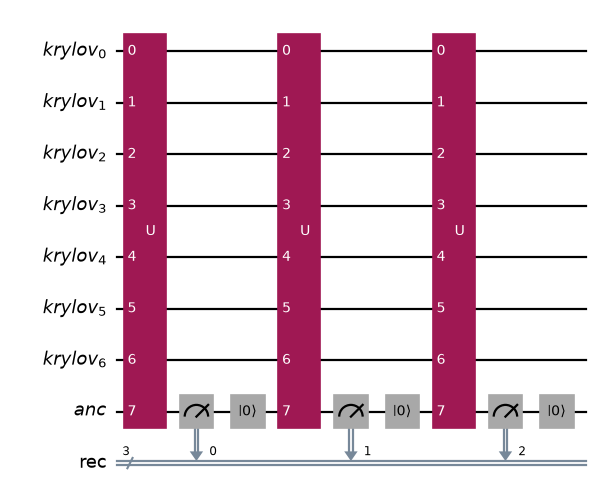

  8 qubits, 100 applications of one gate, depth 300, 300 instructions


In [13]:
qc3 = build_circuit(grid, 3, save_states=False)
fig = qc3.draw('mpl', fold=-1, scale=.8)
fig.savefig(f'{PIC}/circuit_N{N}.png', dpi=160, bbox_inches='tight')
display(fig)

qc_full = build_circuit(grid, N_STEPS, save_states=False)
print(f"  {grid['n_qubits']} qubits, {N_STEPS} applications of one gate, "
      f"depth {qc_full.depth()}, {len(qc_full.data)} instructions")

## 16  One state in, one state out

The minimal statement of the task: the circuit is read only at the end -- the
version that would run on hardware, where `save_statevector` does not exist and
the accepted shots are all one gets.

Here the two readouts part company.  By Proposition 7 the accepted *state* is
exact, so the trace-normalised readout is already exact from a single accepted
shot; the normalisation it uses, $\operatorname{Tr}\rho_S(t)=1$, is a property
of the dynamics and not extra information about the answer.  The readout through
(5.1) instead estimates $\lVert y_t\rVert$ from the acceptance rate and
therefore carries the usual $1/\sqrt{N_{\rm acc}}$ shot noise.

In [14]:
print(f'  read only at t = {N_STEPS*dt_fs:.0f} fs:')
for sh in (256, 1024, 4096):
    pf, pf_tr, isf = run_grid_final(grid, N_STEPS, shots=sh, verbose=False)
    n_ok = int(round(isf['p_success'][-1] * sh))
    print(f"    shots={sh:6d} ({n_ok:6d} accepted, p={isf['p_success'][-1]:.4f})   "
          f"eq.(5.1) readout {np.abs(pf - pops_qutip[N_STEPS]).max():.3e}   "
          f"trace readout {np.abs(pf_tr - pops_qutip[N_STEPS]).max():.3e}")

  read only at t = 1000 fs:


    shots=   256 (   114 accepted, p=0.4453)   eq.(5.1) readout 4.076e-02   trace readout 2.486e-07


    shots=  1024 (   386 accepted, p=0.3770)   eq.(5.1) readout 6.507e-03   trace readout 2.486e-07


    shots=  4096 (  1500 accepted, p=0.3662)   eq.(5.1) readout 8.500e-04   trace readout 2.486e-07


## 17  Summary

| | classical time steps | qubits | deviation from qutip `HEOMSolver` |
|---|---|---|---|
| companion, $K=10$ | 10 | 9 | $5.7\times10^{-2}$ |
| companion, $K=25$ | 25 | 10 | $5.6\times10^{-3}$ |
| companion, $K=40$ | 40 | 11 | $9.0\times10^{-4}$ |
| **this folder, $m=64$** | **0** | **7** | $5.3\times10^{-7}$ |
| **this folder, $m=128$** | **0** | **8** | $5.3\times10^{-7}$ |

The companion qubit counts are for the uncompressed register,
$\lceil\log_2Kd^2\rceil+1$.  Krylov compression shrinks them too, but it cannot
repair the truncation error, and applied to the raw $E$ it is unstable for the
reason given in section 2.

$5.3\times10^{-7}$ is the qutip solver's own integration tolerance -- iterating
the full $2640\times2640$ propagator reproduces the same figure, and the Krylov
truncation error measured against *that* exact trajectory is
$1.9\times10^{-14}$ over 100 steps and $1.7\times10^{-8}$ over 500 steps at
$m=128$.

What made the difference was not a better memory kernel but dropping the memory
kernel altogether: the ADOs already carry the full history, so equation (1.1) is
exact and $K$ disappears.  The single obstruction was that the exact propagator
has $\lVert P\rVert_2=32$ while $\rho(P)=1$ -- and by Theorem 4 that is a
property of the inner product, not of the physics.  Proposition 6 then makes the
compression free, and Proposition 7 makes the post-selected branch exact.